### Data Cleaning and Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings


In [3]:
# Set plotting style for visuals
plt.style.use('ggplot')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [5]:
df = pd.read_csv('Senior Data Analyst Task Transactions.csv')
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns\n")

Loaded dataset with 10000 rows and 12 columns



In [6]:
print("Dataset Columns:")
print(df.columns.tolist())
df.head()

Dataset Columns:
['Transaction_ID', 'User_ID', 'Crypto', 'Transaction_Type', 'Amount', 'Price_Per_Unit', 'Total_Value', 'Transaction_Fee', 'Platform', 'Status', 'Wallet_Type', 'Transaction_Date']


,Transaction_ID,User_ID,Crypto,Transaction_Type,Amount,Price_Per_Unit,Total_Value,Transaction_Fee,Platform,Status,Wallet_Type,Transaction_Date
0,434465,31394,Bitcoin,Withdraw,57.695145,45248.78,2610634.92,114990.70,KuCoin,Completed,Trezor,2024-04-10 09:51:58.222424
1,905397,39627,Solana,Stake,27.708982,48307.43,1338549.71,34560.11,Binance,Failed,Cold Wallet,2023-10-04 09:51:58.222424
2,451293,11506,Cardano,Buy,80.368977,44428.82,3570698.81,38312.76,OKX,Pending,Hot Wallet,2024-11-15 09:51:58.222424
3,841249,84005,XRP,Stake,83.900483,8755.31,734574.74,1396.89,FTX,Completed,Exchange Wallet,2024-02-11 09:51:58.222424
4,762686,66706,Dogecoin,Stake,52.528368,58667.26,3081695.42,19087.58,Kraken,Pending,Exchange Wallet,2023-09-15 09:51:58.222424


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    10000 non-null  int64  
 1   User_ID           10000 non-null  int64  
 2   Crypto            10000 non-null  object 
 3   Transaction_Type  10000 non-null  object 
 4   Amount            10000 non-null  float64
 5   Price_Per_Unit    10000 non-null  float64
 6   Total_Value       10000 non-null  float64
 7   Transaction_Fee   10000 non-null  float64
 8   Platform          10000 non-null  object 
 9   Status            10000 non-null  object 
 10  Wallet_Type       10000 non-null  object 
 11  Transaction_Date  10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [8]:
df.describe()

,Transaction_ID,User_ID,Amount,Price_Per_Unit,Total_Value,Transaction_Fee
count,10000.000000,10000.00000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,547132.392100,55176.38050,50.120755,29888.220522,1.506658e+06,37555.080850
std,262163.276431,25823.90504,28.902577,17215.202926,1.327017e+06,43871.976036
min,100027.000000,10016.00000,0.024363,10.270000,3.665000e+01,0.040000
25%,318120.750000,32775.00000,24.889845,15240.167500,4.124107e+05,6007.977500
50%,547635.000000,55643.00000,49.887958,29823.745000,1.124990e+06,21182.080000
75%,775336.000000,77450.00000,75.319944,44728.790000,2.310646e+06,53563.732500
max,999919.000000,99986.00000,99.997361,59995.760000,5.881193e+06,287527.830000


In [9]:
# Check for missing values
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [10]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values by Column:")
print(missing_values)

Missing Values by Column:
Transaction_ID      0
User_ID             0
Crypto              0
Transaction_Type    0
Amount              0
Price_Per_Unit      0
Total_Value         0
Transaction_Fee     0
Platform            0
Status              0
Wallet_Type         0
Transaction_Date    0
dtype: int64


In [11]:
# Convert date column to datetime
print("Converting Transaction_Date to datetime format...")
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
print("Sample of Transaction_Date after conversion:")
print(df['Transaction_Date'].head())

Converting Transaction_Date to datetime format...
Sample of Transaction_Date after conversion:
0   2024-04-10 09:51:58.222424
1   2023-10-04 09:51:58.222424
2   2024-11-15 09:51:58.222424
3   2024-02-11 09:51:58.222424
4   2023-09-15 09:51:58.222424
Name: Transaction_Date, dtype: datetime64[ns]


In [12]:
# Extract additional date features
print("Extracting additional date features...")
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Day'] = df['Transaction_Date'].dt.day
df['DayOfWeek'] = df['Transaction_Date'].dt.dayofweek
df['YearMonth'] = df['Transaction_Date'].dt.strftime('%Y-%m')
print("Sample of data with new date features:")
print(df[['Transaction_Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'YearMonth']].head())

Extracting additional date features...
Sample of data with new date features:
            Transaction_Date  Year  Month  Day  DayOfWeek YearMonth
0 2024-04-10 09:51:58.222424  2024      4   10          2   2024-04
1 2023-10-04 09:51:58.222424  2023     10    4          2   2023-10
2 2024-11-15 09:51:58.222424  2024     11   15          4   2024-11
3 2024-02-11 09:51:58.222424  2024      2   11          6   2024-02
4 2023-09-15 09:51:58.222424  2023      9   15          4   2023-09


In [13]:
# Check value consistency: Total_Value should be approximately Amount * Price_Per_Unit
print("Verifying calculation consistency (Total_Value ≈ Amount * Price_Per_Unit)...")
df['Calculated_Value'] = df['Amount'] * df['Price_Per_Unit']
df['Value_Difference'] = abs(df['Total_Value'] - df['Calculated_Value'])
df['Value_Diff_Percentage'] = (df['Value_Difference'] / df['Total_Value']) * 100

significant_diff_count = df[df['Value_Diff_Percentage'] > 1].shape[0]
significant_diff_percentage = (significant_diff_count / len(df)) * 100
print(f"Number of rows with >1% difference: {significant_diff_count} ({significant_diff_percentage:.2f}% of data)")

if significant_diff_count > 0:
    print("Sample of rows with significant differences:")
    df[df['Value_Diff_Percentage'] > 1][['Amount', 'Price_Per_Unit', 'Total_Value', 'Calculated_Value', 'Value_Diff_Percentage']].head()

Verifying calculation consistency (Total_Value ≈ Amount * Price_Per_Unit)...
Number of rows with >1% difference: 0 (0.00% of data)


In [14]:
# Calculate fee percentage for later analysis
print("Calculating fee percentage...")
df['Fee_Percentage'] = (df['Transaction_Fee'] / df['Total_Value']) * 100
print("Sample of Fee_Percentage data:")
df[['Total_Value', 'Transaction_Fee', 'Fee_Percentage']].head()

Calculating fee percentage...
Sample of Fee_Percentage data:


,Total_Value,Transaction_Fee,Fee_Percentage
0,2610634.92,114990.70,4.404702
1,1338549.71,34560.11,2.581907
2,3570698.81,38312.76,1.072977
3,734574.74,1396.89,0.190163
4,3081695.42,19087.58,0.619386


In [15]:
# Check for outliers in fee percentage
low_fee_pct = df['Fee_Percentage'].quantile(0.01)
high_fee_pct = df['Fee_Percentage'].quantile(0.99)
print(f"Fee percentage - 1st percentile: {low_fee_pct:.2f}%, 99th percentile: {high_fee_pct:.2f}%")

Fee percentage - 1st percentile: 0.06%, 99th percentile: 4.96%


In [16]:

# Check for any future dates (data quality)
future_dates = df[df['Transaction_Date'] > datetime.now()].shape[0]
print(f"Number of transactions with future dates: {future_dates}")

if future_dates > 0:
    print("Sample of future dates:")
    df[df['Transaction_Date'] > datetime.now()]['Transaction_Date'].head()

Number of transactions with future dates: 0


In [17]:
# Check categorical values
print("Unique values in categorical columns:")
categorical_cols = ['Crypto', 'Transaction_Type', 'Platform', 'Status', 'Wallet_Type']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values - {', '.join(df[col].unique())}")

Unique values in categorical columns:
Crypto: 10 unique values - Bitcoin, Solana, Cardano, XRP, Dogecoin, BNB, Polkadot, Litecoin, Avalanche, Ethereum
Transaction_Type: 5 unique values - Withdraw, Stake, Buy, Sell, Transfer
Platform: 7 unique values - KuCoin, Binance, OKX, FTX, Kraken, Coinbase, Huobi
Status: 3 unique values - Completed, Failed, Pending
Wallet_Type: 5 unique values - Trezor, Cold Wallet, Hot Wallet, Exchange Wallet, Ledger


In [18]:
# Final cleaned dataset
print("Final cleaned dataset shape:", df.shape)
df.head()

Final cleaned dataset shape: (10000, 21)


,Transaction_ID,User_ID,Crypto,Transaction_Type,Amount,Price_Per_Unit,Total_Value,Transaction_Fee,Platform,Status,...,Transaction_Date,Year,Month,Day,DayOfWeek,YearMonth,Calculated_Value,Value_Difference,Value_Diff_Percentage,Fee_Percentage
0,434465,31394,Bitcoin,Withdraw,57.695145,45248.78,2610634.92,114990.70,KuCoin,Completed,...,2024-04-10 09:51:58.222424,2024,4,10,2,2024-04,2.610635e+06,0.003173,1.215451e-07,4.404702
1,905397,39627,Solana,Stake,27.708982,48307.43,1338549.71,34560.11,Binance,Failed,...,2023-10-04 09:51:58.222424,2023,10,4,2,2023-10,1.338550e+06,0.001664,1.242942e-07,2.581907
2,451293,11506,Cardano,Buy,80.368977,44428.82,3570698.81,38312.76,OKX,Pending,...,2024-11-15 09:51:58.222424,2024,11,15,4,2024-11,3.570699e+06,0.002717,7.609547e-08,1.072977
3,841249,84005,XRP,Stake,83.900483,8755.31,734574.74,1396.89,FTX,Completed,...,2024-02-11 09:51:58.222424,2024,2,11,6,2024-02,7.345747e+05,0.002185,2.974878e-07,0.190163
4,762686,66706,Dogecoin,Stake,52.528368,58667.26,3081695.42,19087.58,Kraken,Pending,...,2023-09-15 09:51:58.222424,2023,9,15,4,2023-09,3.081695e+06,0.002832,9.188709e-08,0.619386


In [19]:
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100

print("Transaction Status Distribution:")
for status, count in status_counts.items():
    print(f"{status}: {count} transactions ({status_pct[status]:.2f}%)")

Transaction Status Distribution:
Failed: 3353 transactions (33.53%)
Pending: 3325 transactions (33.25%)
Completed: 3322 transactions (33.22%)


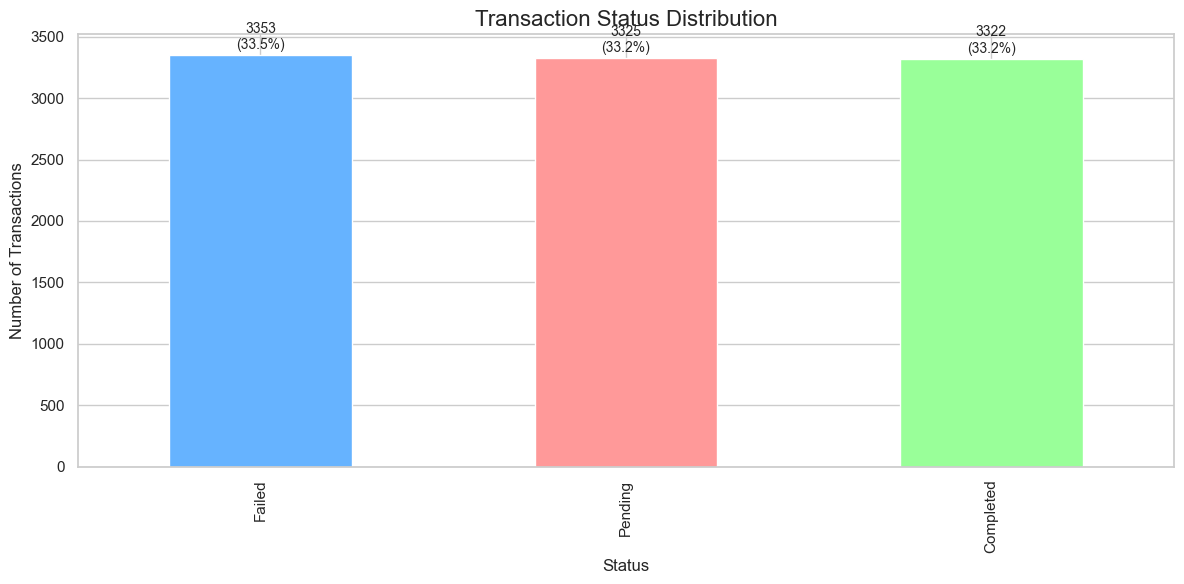

In [23]:
# Plot Status Distribution
plt.figure(figsize=(12, 6))
ax = status_counts.plot(kind='bar', color=['#66b3ff', '#ff9999', '#99ff99'])
plt.title('Transaction Status Distribution', fontsize=16)
plt.xlabel('Status')
plt.ylabel('Number of Transactions')
# Add count labels above bars
for i, v in enumerate(status_counts):
    ax.text(i, v + 50, f"{v}\n({status_pct.iloc[i]:.1f}%)", 
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Transaction Status Distribution:
Failed: 3353 transactions (33.53%)
Pending: 3325 transactions (33.25%)
Completed: 3322 transactions (33.22%)


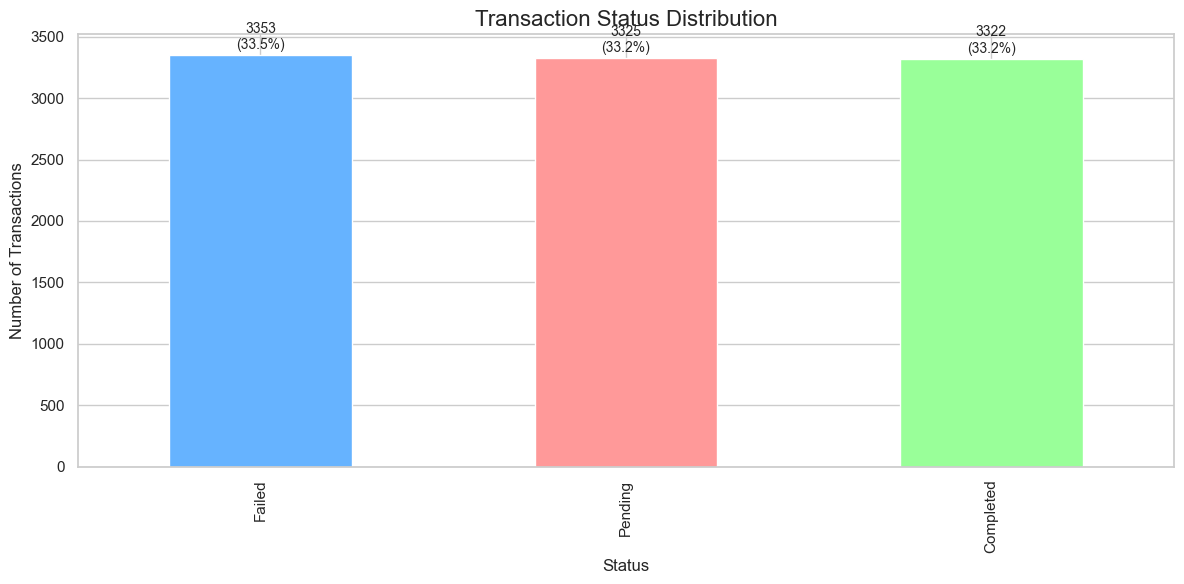

In [25]:
# Plot Status Distribution
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100

print("Transaction Status Distribution:")
for status, count in status_counts.items():
    print(f"{status}: {count} transactions ({status_pct[status]:.2f}%)")
    
plt.figure(figsize=(12, 6))
ax = status_counts.plot(kind='bar', color=['#66b3ff', '#ff9999', '#99ff99'])
plt.title('Transaction Status Distribution', fontsize=16)
plt.xlabel('Status')
plt.ylabel('Number of Transactions')

# Add count labels above bars
for i, v in enumerate(status_counts):
    ax.text(i, v + 50, f"{v}\n({status_pct.iloc[i]:.1f}%)", 
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Cryptocurrency Transaction Counts:
Crypto
Polkadot     1077
Ethereum     1042
Avalanche    1009
Solana       1000
Cardano       997
Dogecoin      997
Bitcoin       991
BNB           973
XRP           964
Litecoin      950
Name: count, dtype: int64

Top Cryptocurrencies by Total Volume:
Polkadot: $1,648,498,379.71
Ethereum: $1,578,548,739.81
Bitcoin: $1,576,560,594.18
Cardano: $1,547,730,763.06
BNB: $1,499,291,857.83
Avalanche: $1,490,421,587.91
Solana: $1,474,046,004.49
Dogecoin: $1,452,350,589.94
XRP: $1,401,907,272.06
Litecoin: $1,397,225,389.85

Top Cryptocurrencies by Average Transaction Value:
Bitcoin: $1,590,878.50
Cardano: $1,552,387.93
BNB: $1,540,896.05
Polkadot: $1,530,639.16
Ethereum: $1,514,922.02

Cryptocurrency Success Rates:
Bitcoin: 34.41%
BNB: 34.33%
Dogecoin: 34.30%
Ethereum: 34.26%
Cardano: 34.10%
Polkadot: 33.52%
Litecoin: 33.05%
Avalanche: 32.71%
XRP: 31.64%
Solana: 29.80%


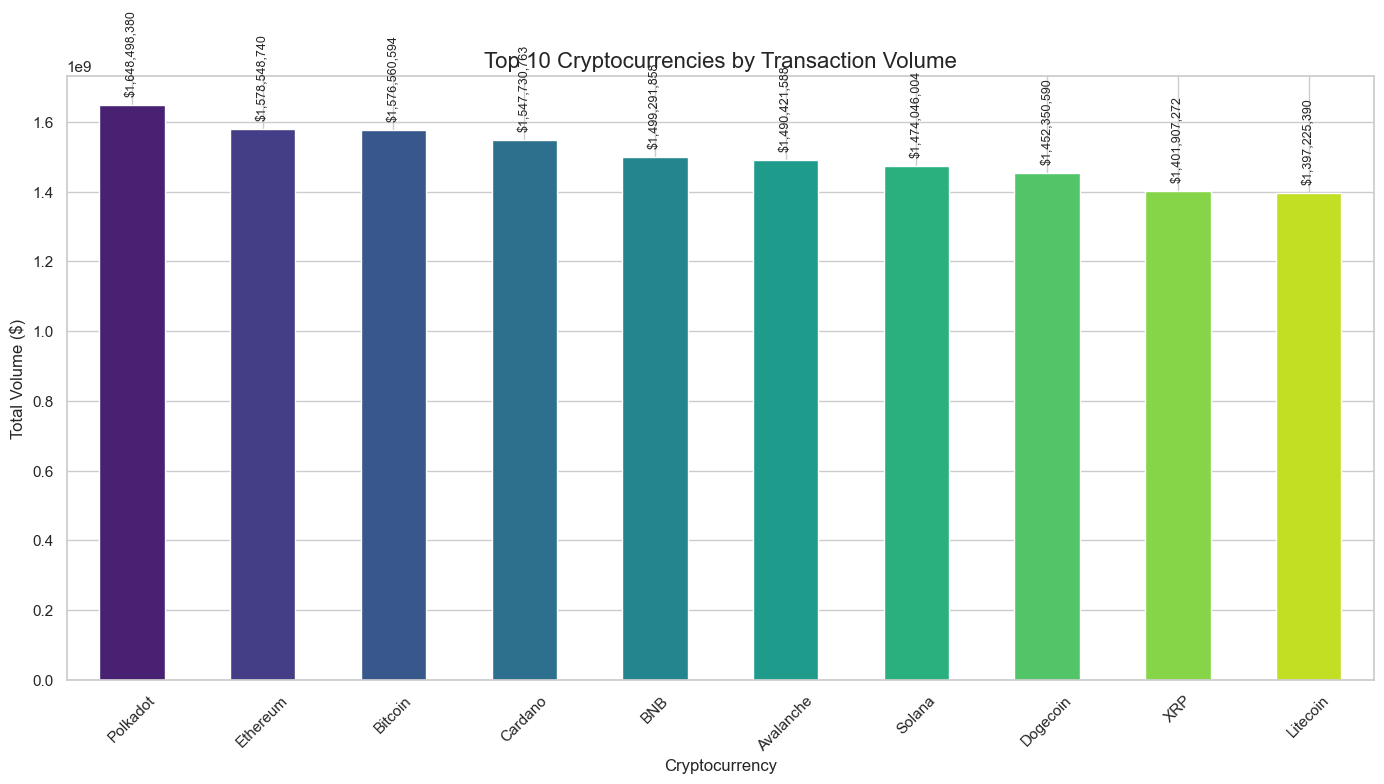

In [28]:
# Plot crypto
crypto_counts = df['Crypto'].value_counts()
crypto_volume = df.groupby('Crypto')['Total_Value'].sum().sort_values(ascending=False)
crypto_avg_value = df.groupby('Crypto')['Total_Value'].mean().sort_values(ascending=False)
crypto_success_rate = df[df['Status'] == 'Completed'].groupby('Crypto').size() / crypto_counts * 100

print("Cryptocurrency Transaction Counts:")
print(crypto_counts)

print("\nTop Cryptocurrencies by Total Volume:")
for crypto, volume in crypto_volume.items():
    print(f"{crypto}: ${volume:,.2f}")

print("\nTop Cryptocurrencies by Average Transaction Value:")
for crypto, avg in crypto_avg_value.head(5).items():
    print(f"{crypto}: ${avg:,.2f}")

print("\nCryptocurrency Success Rates:")
for crypto, rate in crypto_success_rate.sort_values(ascending=False).items():
    print(f"{crypto}: {rate:.2f}%")
plt.figure(figsize=(14, 8))
ax = crypto_volume.head(10).plot(kind='bar', color=sns.color_palette('viridis', len(crypto_volume.head(10))))
plt.title('Top 10 Cryptocurrencies by Transaction Volume', fontsize=16)
plt.xlabel('Cryptocurrency')
plt.ylabel('Total Volume ($)')
plt.xticks(rotation=45)

# Add volume labels
for i, v in enumerate(crypto_volume.head(10)):
    ax.text(i, v + (crypto_volume.head(10).max() * 0.02), f"${v:,.0f}", 
            ha='center', fontsize=9, rotation=90)

plt.tight_layout()
plt.show()
    

Platform Transaction Counts:
Platform
Coinbase    1515
KuCoin      1484
Huobi       1425
Kraken      1419
FTX         1404
Binance     1395
OKX         1358
Name: count, dtype: int64

Platform Total Volume:
Coinbase: $2,288,498,227.48
KuCoin: $2,250,109,624.30
Huobi: $2,242,570,892.98
FTX: $2,102,561,102.53
Binance: $2,098,570,098.34
Kraken: $2,072,742,945.31
OKX: $2,011,528,287.90

Platform Success Rates:
Coinbase: 36.30%
Binance: 34.41%
OKX: 33.21%
Kraken: 32.98%
KuCoin: 32.41%
FTX: 31.98%
Huobi: 31.09%

Platform Average Fee Percentages:
Binance: 2.45%
Kraken: 2.48%
KuCoin: 2.49%
FTX: 2.52%
Huobi: 2.52%
OKX: 2.56%
Coinbase: 2.56%


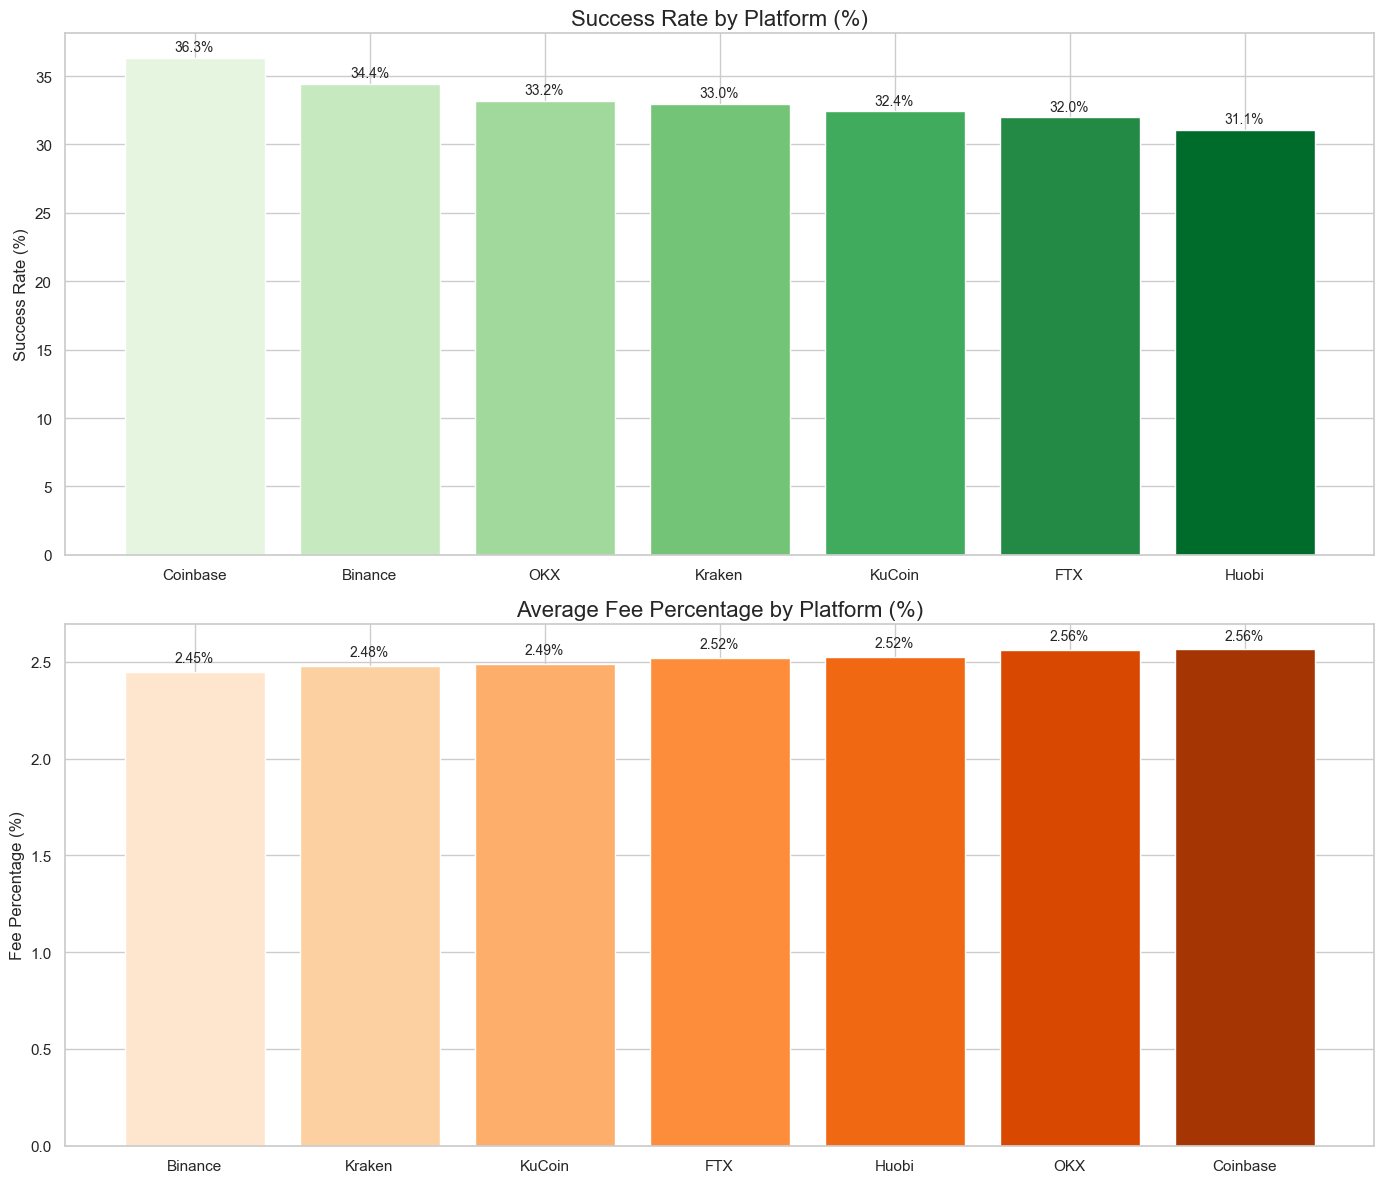

In [30]:
# Plot Platforms
platform_counts = df['Platform'].value_counts()
platform_volume = df.groupby('Platform')['Total_Value'].sum().sort_values(ascending=False)
platform_success_rate = df[df['Status'] == 'Completed'].groupby('Platform').size() / platform_counts * 100
platform_fee_pct = df.groupby('Platform')['Fee_Percentage'].mean().sort_values()

print("Platform Transaction Counts:")
print(platform_counts)

print("\nPlatform Total Volume:")
for platform, volume in platform_volume.items():
    print(f"{platform}: ${volume:,.2f}")

print("\nPlatform Success Rates:")
for platform, rate in platform_success_rate.sort_values(ascending=False).items():
    print(f"{platform}: {rate:.2f}%")

print("\nPlatform Average Fee Percentages:")
for platform, fee in platform_fee_pct.items():
    print(f"{platform}: {fee:.2f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

bars1 = ax1.bar(platform_success_rate.sort_values(ascending=False).index, 
         platform_success_rate.sort_values(ascending=False).values,
         color=sns.color_palette('Greens', len(platform_success_rate)))
ax1.set_title('Success Rate by Platform (%)', fontsize=16)
ax1.set_ylabel('Success Rate (%)')

for i, v in enumerate(platform_success_rate.sort_values(ascending=False)):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

bars2 = ax2.bar(platform_fee_pct.index, platform_fee_pct.values,
         color=sns.color_palette('Oranges', len(platform_fee_pct)))
ax2.set_title('Average Fee Percentage by Platform (%)', fontsize=16)
ax2.set_ylabel('Fee Percentage (%)')

for i, v in enumerate(platform_fee_pct):
    ax2.text(i, v + 0.05, f"{v:.2f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Transaction Type Counts:
Stake: 2052 (20.5%)
Sell: 2036 (20.4%)
Buy: 2008 (20.1%)
Transfer: 1972 (19.7%)
Withdraw: 1932 (19.3%)

Transaction Type Success Rates:
Withdraw: 34.11%
Sell: 33.74%
Stake: 33.14%
Buy: 32.72%
Transfer: 32.40%

Average Transaction Value by Type:
Buy: $1,545,108.43
Transfer: $1,522,016.82
Withdraw: $1,497,454.38
Sell: $1,486,393.79
Stake: $1,483,044.18


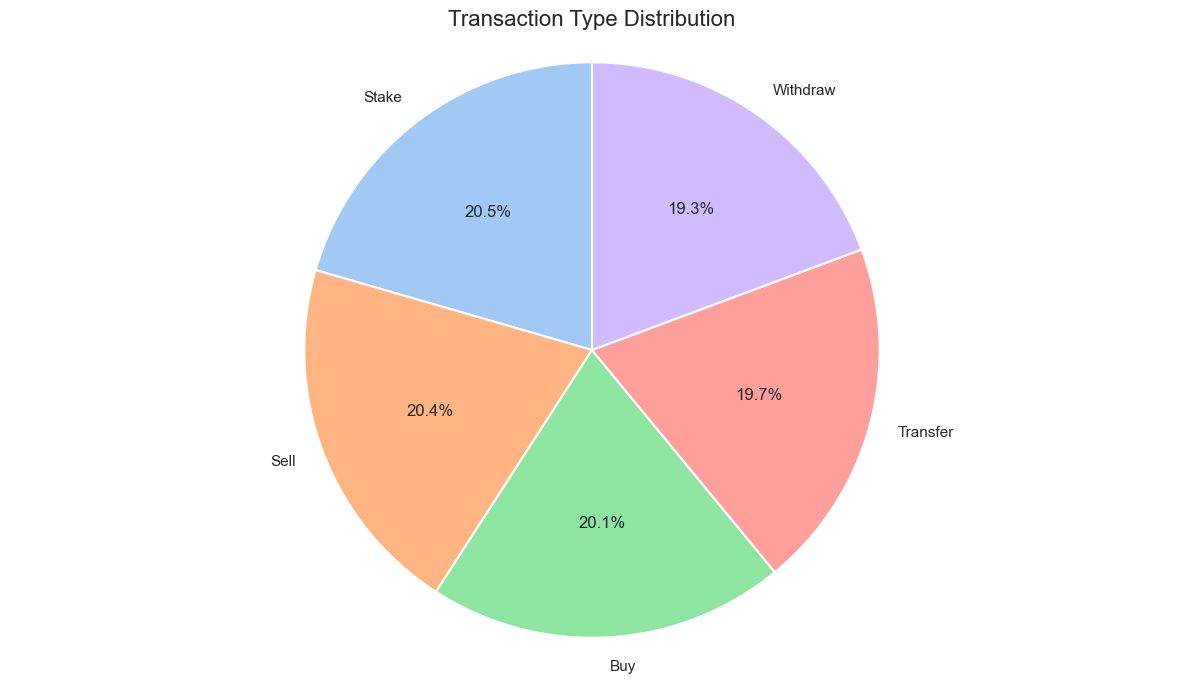

In [31]:
# Plot Type count
type_counts = df['Transaction_Type'].value_counts()
type_success_rate = df[df['Status'] == 'Completed'].groupby('Transaction_Type').size() / type_counts * 100
type_avg_value = df.groupby('Transaction_Type')['Total_Value'].mean().sort_values(ascending=False)
type_avg_fee = df.groupby('Transaction_Type')['Transaction_Fee'].mean()

print("Transaction Type Counts:")
for t_type, count in type_counts.items():
    print(f"{t_type}: {count} ({count/len(df)*100:.1f}%)")

print("\nTransaction Type Success Rates:")
for t_type, rate in type_success_rate.sort_values(ascending=False).items():
    print(f"{t_type}: {rate:.2f}%")

print("\nAverage Transaction Value by Type:")
for t_type, value in type_avg_value.items():
    print(f"{t_type}: ${value:,.2f}")

plt.figure(figsize=(12, 7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('pastel', len(type_counts)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.axis('equal')
plt.title('Transaction Type Distribution', fontsize=16)
plt.tight_layout()
plt.show()

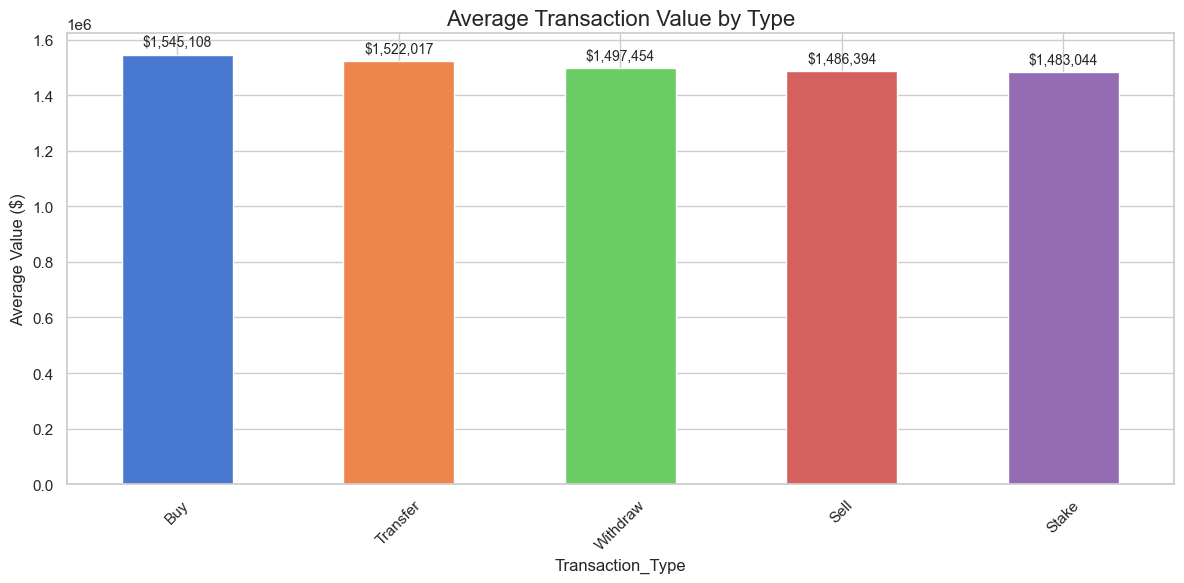

In [32]:
# Plot Average Transaction Value by Type
plt.figure(figsize=(12, 6))
ax = type_avg_value.plot(kind='bar', color=sns.color_palette('muted', len(type_avg_value)))
plt.title('Average Transaction Value by Type', fontsize=16)
plt.ylabel('Average Value ($)')
plt.xticks(rotation=45)

for i, v in enumerate(type_avg_value):
    ax.text(i, v + (type_avg_value.max() * 0.02), f"${v:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Wallet Type Distribution:
Hot Wallet: 2064 (20.6%)
Exchange Wallet: 2018 (20.2%)
Ledger: 1983 (19.8%)
Trezor: 1971 (19.7%)
Cold Wallet: 1964 (19.6%)

Wallet Type Success Rates:
Cold Wallet: 33.91%
Exchange Wallet: 33.60%
Hot Wallet: 33.43%
Ledger: 32.73%
Trezor: 32.42%


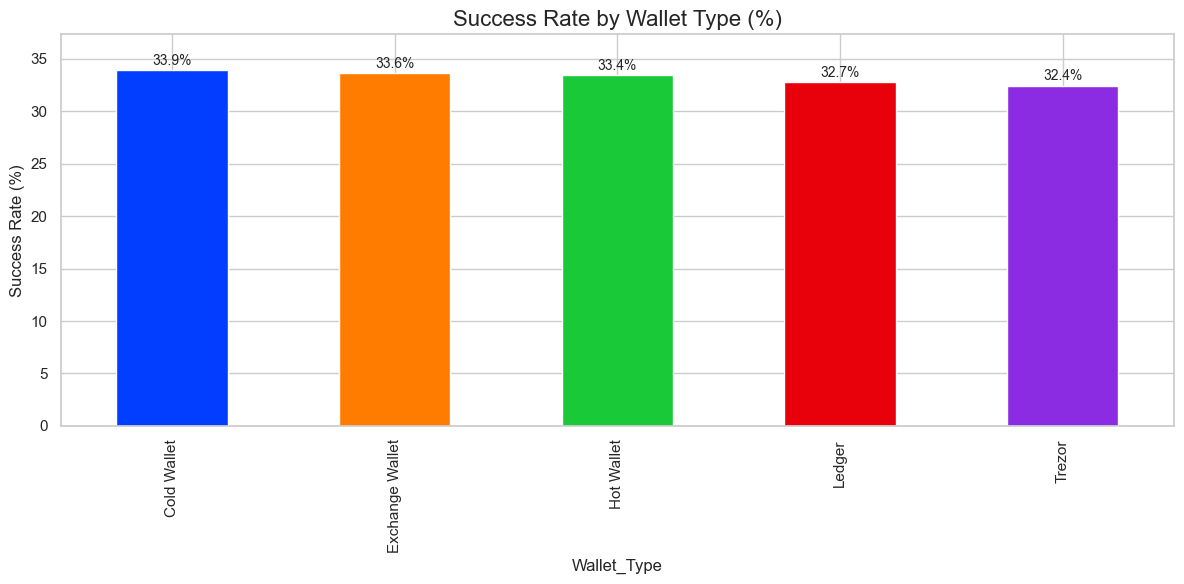

In [40]:
# Analyze wallet types
wallet_counts = df['Wallet_Type'].value_counts()
wallet_success_rate = df[df['Status'] == 'Completed'].groupby('Wallet_Type').size() / wallet_counts * 100
wallet_avg_value = df.groupby('Wallet_Type')['Total_Value'].mean()

print("Wallet Type Distribution:")
for wallet, count in wallet_counts.items():
    print(f"{wallet}: {count} ({count/len(df)*100:.1f}%)")

print("\nWallet Type Success Rates:")
for wallet, rate in wallet_success_rate.sort_values(ascending=False).items():
    print(f"{wallet}: {rate:.2f}%")
plt.figure(figsize=(12, 6))

ax = wallet_success_rate.sort_values(ascending=False).plot(kind='bar', 
color=sns.color_palette('bright', len(wallet_success_rate)))
plt.title('Success Rate by Wallet Type (%)', fontsize=16)
plt.ylabel('Success Rate (%)')
plt.ylim(0, wallet_success_rate.max() * 1.1)

# Add percentage labels
for i, v in enumerate(wallet_success_rate.sort_values(ascending=False)):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()    

<Figure size 1400x800 with 0 Axes>

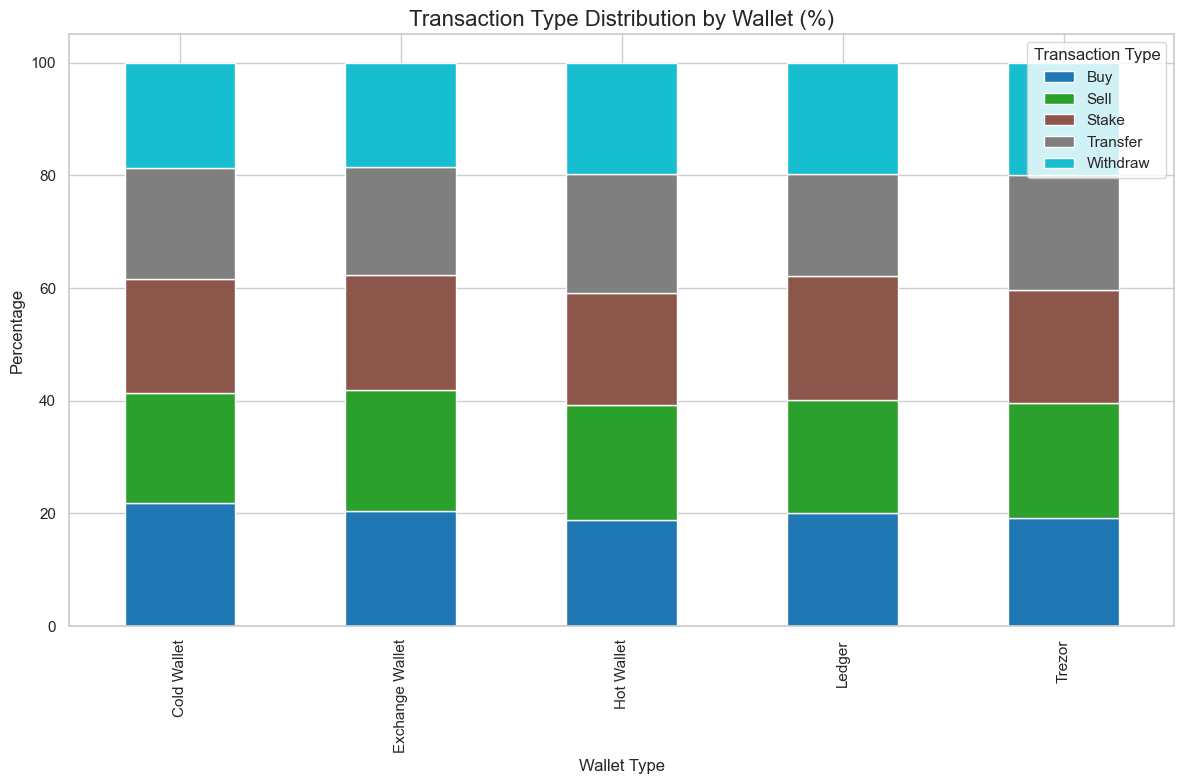

In [41]:
# Plot Transaction Type Distribution by Wallet
wallet_type_pivot = pd.crosstab(df['Wallet_Type'], df['Transaction_Type'])
wallet_type_pivot_pct = wallet_type_pivot.div(wallet_type_pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
wallet_type_pivot_pct.plot(kind='bar', stacked=True, colormap='tab10')
plt.title('Transaction Type Distribution by Wallet (%)', fontsize=16)
plt.xlabel('Wallet Type')
plt.ylabel('Percentage')
plt.legend(title='Transaction Type')
plt.tight_layout()
plt.show()

Analyse Time Based Trends

Monthly Transaction Counts:
YearMonth
2023-02     12
2023-03    439
2023-04    388
2023-05    442
2023-06    410
2023-07    376
2023-08    405
2023-09    401
2023-10    444
2023-11    432
2023-12    417
2024-01    436
2024-02    375
2024-03    409
2024-04    433
2024-05    457
2024-06    396
2024-07    418
2024-08    428
2024-09    404
2024-10    445
2024-11    367
2024-12    425
2025-01    461
2025-02    380
dtype: int64

Monthly Transaction Volume:
2023-02: $16,549,474.79
2023-03: $636,646,799.85
2023-04: $577,403,086.89
2023-05: $707,667,041.18
2023-06: $629,172,952.99
2023-07: $539,317,402.99
2023-08: $597,704,291.89
2023-09: $572,850,847.47
2023-10: $666,793,081.60
2023-11: $617,352,027.06
2023-12: $662,211,458.86
2024-01: $658,676,625.88
2024-02: $557,864,589.31
2024-03: $626,180,987.37
2024-04: $651,645,727.33
2024-05: $728,378,258.67
2024-06: $576,888,224.37
2024-07: $628,619,354.73
2024-08: $663,662,345.51
2024-09: $625,482,705.97
2024-10: $711,520,983.96
2024-11: $549,270,388

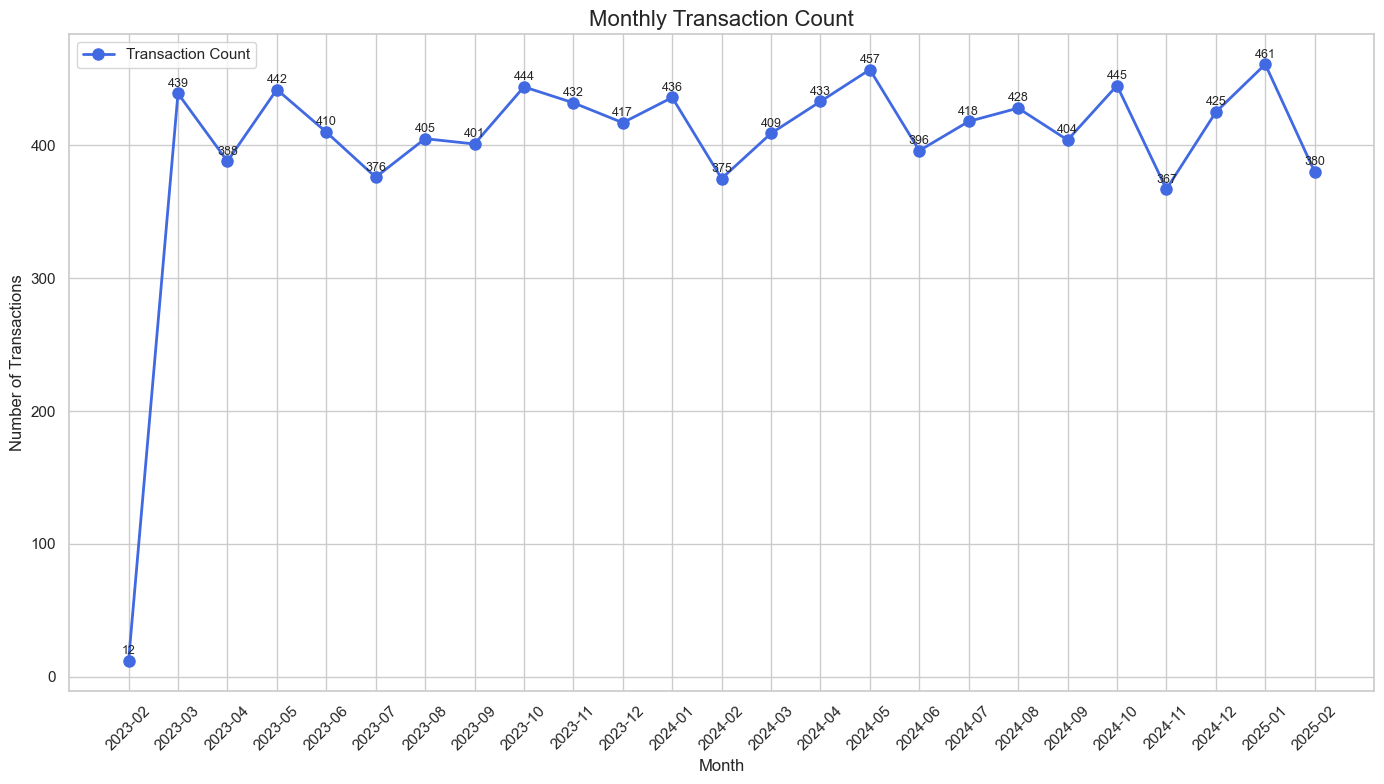

In [42]:
# Monthly transaction trends
monthly_count = df.groupby('YearMonth').size()
monthly_volume = df.groupby('YearMonth')['Total_Value'].sum()
monthly_success = df[df['Status'] == 'Completed'].groupby('YearMonth').size() / monthly_count * 100

print("Monthly Transaction Counts:")
print(monthly_count)

print("\nMonthly Transaction Volume:")
for month, volume in monthly_volume.items():
    print(f"{month}: ${volume:,.2f}")

print("\nMonthly Success Rates:")
for month, rate in monthly_success.items():
    print(f"{month}: {rate:.2f}%")

plt.figure(figsize=(14, 8))
plt.plot(monthly_count.index, monthly_count.values, marker='o', linestyle='-', 
         color='royalblue', linewidth=2, markersize=8, label='Transaction Count')

for i, v in enumerate(monthly_count.values):
    plt.text(i, v + 5, f"{v}", ha='center', fontsize=9)

plt.title('Monthly Transaction Count', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

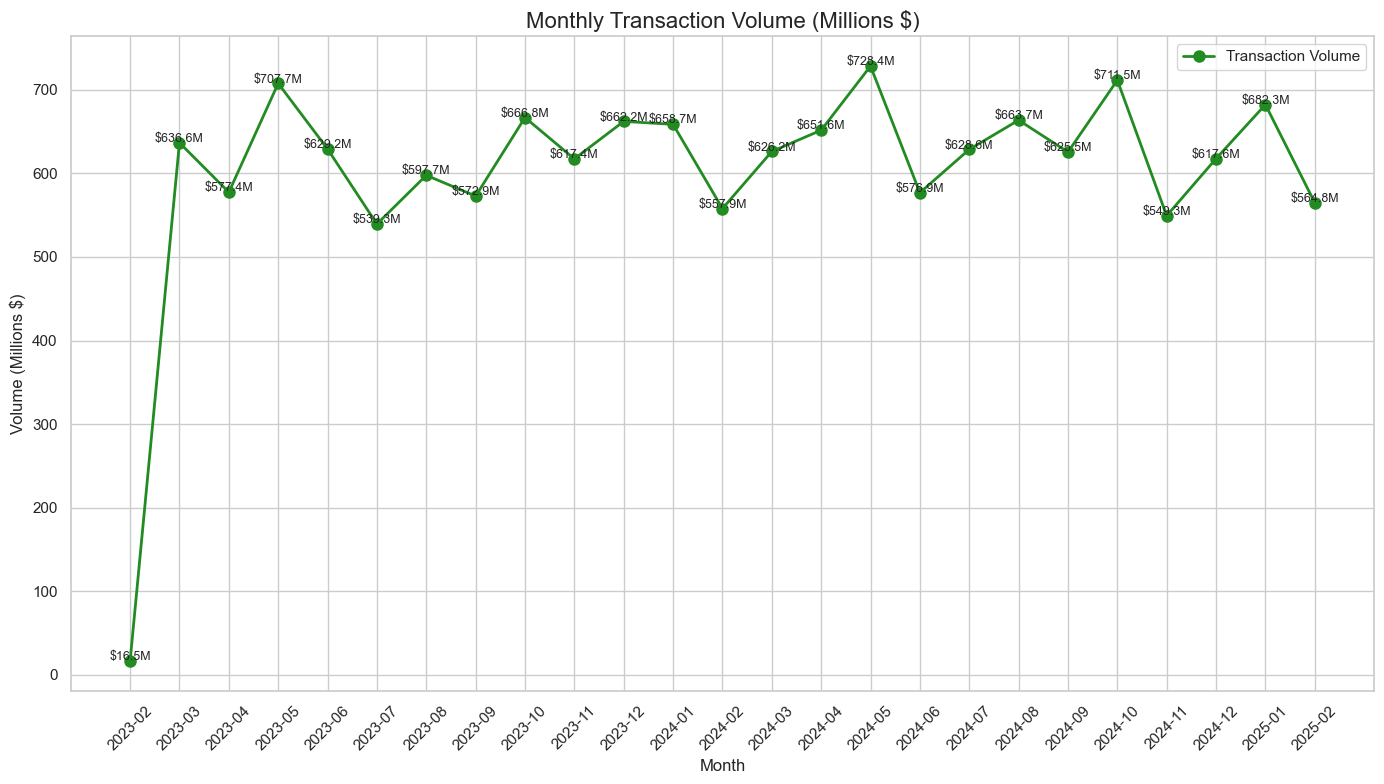

In [43]:
# Plot Monthly Transaction Volume
plt.figure(figsize=(14, 8))
plt.plot(monthly_volume.index, monthly_volume.values / 1e6, marker='o', linestyle='-', 
         color='forestgreen', linewidth=2, markersize=8, label='Transaction Volume')

for i, v in enumerate(monthly_volume.values / 1e6):
    plt.text(i, v + 1, f"${v:.1f}M", ha='center', fontsize=9)

plt.title('Monthly Transaction Volume (Millions $)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Volume (Millions $)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

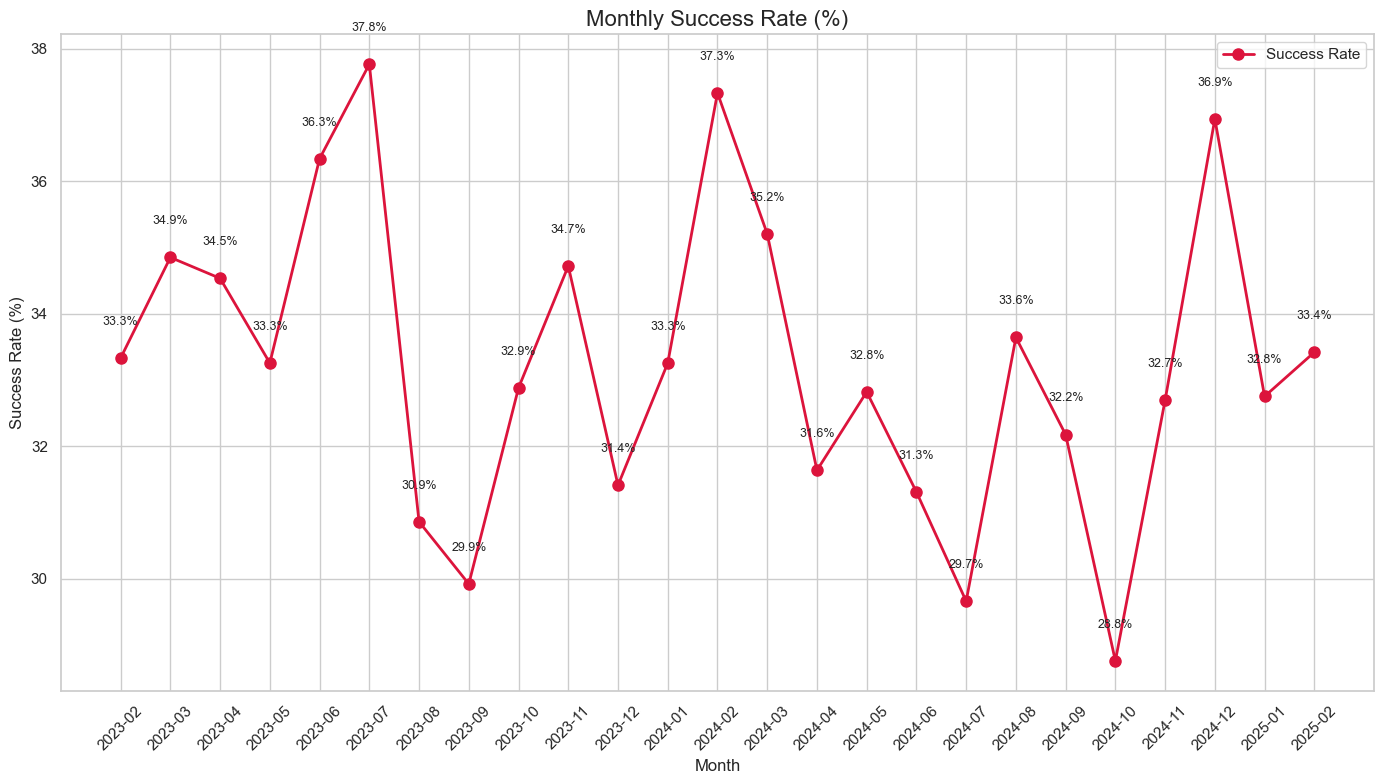

In [44]:
# Plot Monthly Success Rate
plt.figure(figsize=(14, 8))
plt.plot(monthly_success.index, monthly_success.values, marker='o', linestyle='-', 
         color='crimson', linewidth=2, markersize=8, label='Success Rate')

for i, v in enumerate(monthly_success.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.title('Monthly Success Rate (%)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Success Rate (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Transaction Fee Statistics:
Average Fee: $37,555.08
Median Fee: $21,182.08
Min Fee: $0.04
Max Fee: $287,527.83

Overall Fee to Transaction Value Ratio: 2.49%


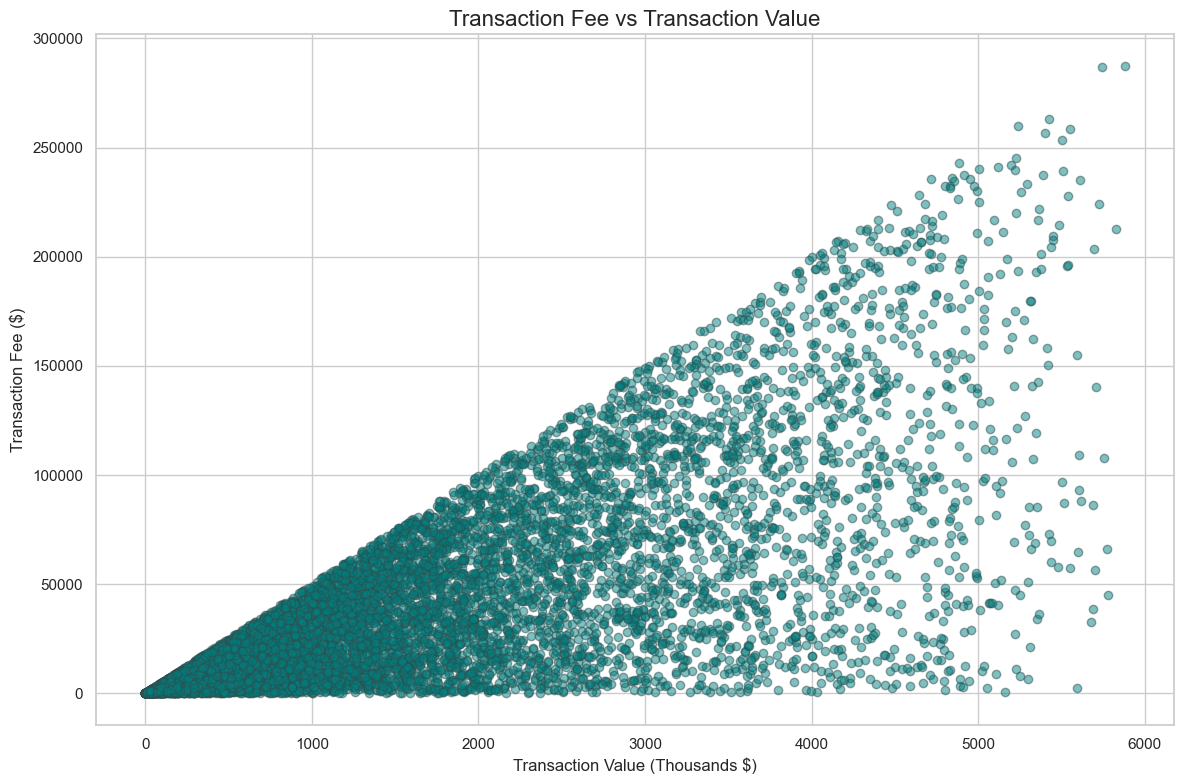

In [45]:
# Analyze fee structure
fee_stats = df['Transaction_Fee'].describe()
fee_to_value_ratio = (df['Transaction_Fee'].sum() / df['Total_Value'].sum()) * 100

print("Transaction Fee Statistics:")
print(f"Average Fee: ${fee_stats['mean']:,.2f}")
print(f"Median Fee: ${fee_stats['50%']:,.2f}")
print(f"Min Fee: ${fee_stats['min']:,.2f}")
print(f"Max Fee: ${fee_stats['max']:,.2f}")
print(f"\nOverall Fee to Transaction Value Ratio: {fee_to_value_ratio:.2f}%")

plt.figure(figsize=(12, 8))
plt.scatter(df['Total_Value'] / 1000, df['Transaction_Fee'], 
            alpha=0.5, color='teal', edgecolors='darkslategray')
plt.title('Transaction Fee vs Transaction Value', fontsize=16)
plt.xlabel('Transaction Value (Thousands $)')
plt.ylabel('Transaction Fee ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

Key Insights and Patterns

Success Rate Comparison Across Different Factors:
Top Performing Combinations (Success Rate):
FTX + Cardano + Stake: 65.00%
KuCoin + Litecoin + Withdraw: 63.64%
Coinbase + Polkadot + Sell: 58.06%
Coinbase + Bitcoin + Withdraw: 57.58%
OKX + Ethereum + Sell: 57.14%
Fee Structure by Transaction Value Category:


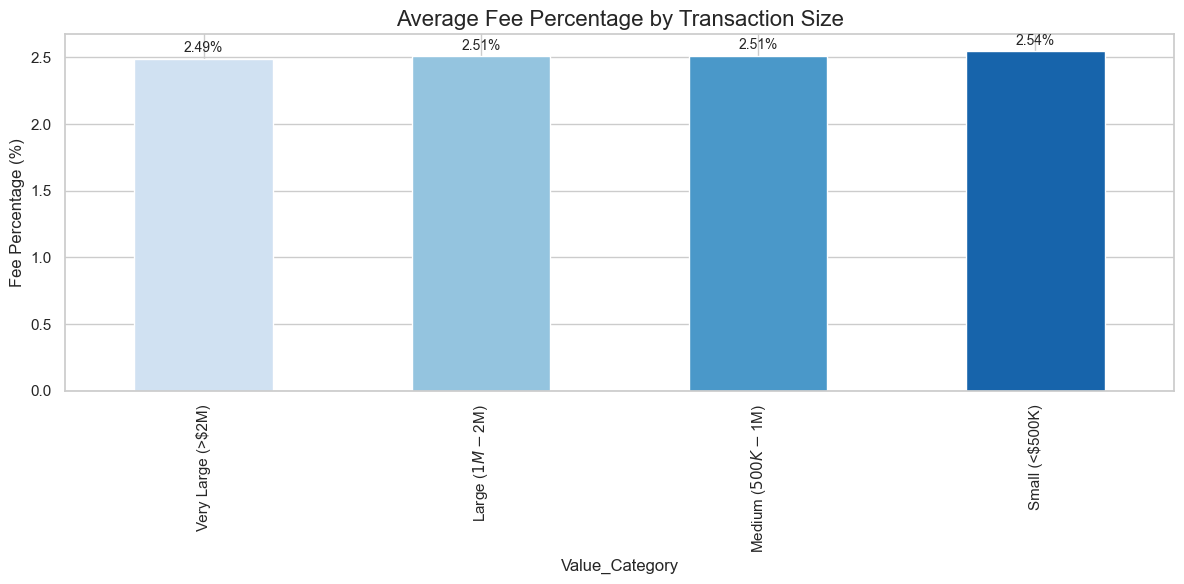

In [49]:
# Create a summary table of success rates
success_factors = pd.DataFrame({
    'Platform Success Rate': platform_success_rate.sort_values(ascending=False),
    'Crypto Success Rate': crypto_success_rate.sort_values(ascending=False),
    'Transaction Type Success Rate': type_success_rate.sort_values(ascending=False),
    'Wallet Type Success Rate': wallet_success_rate.sort_values(ascending=False)
})
print("Success Rate Comparison Across Different Factors:")

print("Top Performing Combinations (Success Rate):")
top_combinations = df.groupby(['Platform', 'Crypto', 'Transaction_Type'])['Status'].apply(
    lambda x: (x == 'Completed').mean() * 100).sort_values(ascending=False).head(5)

for (platform, crypto, tx_type), rate in top_combinations.items():
    print(f"{platform} + {crypto} + {tx_type}: {rate:.2f}%")

def categorize_value(value):
    if value < 500000:
        return 'Small (<$500K)'
    elif value < 1000000:
        return 'Medium ($500K-$1M)'
    elif value < 2000000:
        return 'Large ($1M-$2M)'
    else:
        return 'Very Large (>$2M)'

df['Value_Category'] = df['Total_Value'].apply(categorize_value)

value_category_stats = df.groupby('Value_Category').agg({
    'Transaction_ID': 'count',
    'Total_Value': 'sum',
    'Transaction_Fee': 'mean',
    'Fee_Percentage': 'mean'
}).rename(columns={'Transaction_ID': 'Count'}).sort_values('Fee_Percentage')

print("Fee Structure by Transaction Value Category:")
value_category_stats

plt.figure(figsize=(12, 6))
ax = value_category_stats['Fee_Percentage'].plot(kind='bar', 
                                                color=sns.color_palette('Blues', len(value_category_stats)))
plt.title('Average Fee Percentage by Transaction Size', fontsize=16)
plt.ylabel('Fee Percentage (%)')

for i, v in enumerate(value_category_stats['Fee_Percentage']):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Correlation Matrix:


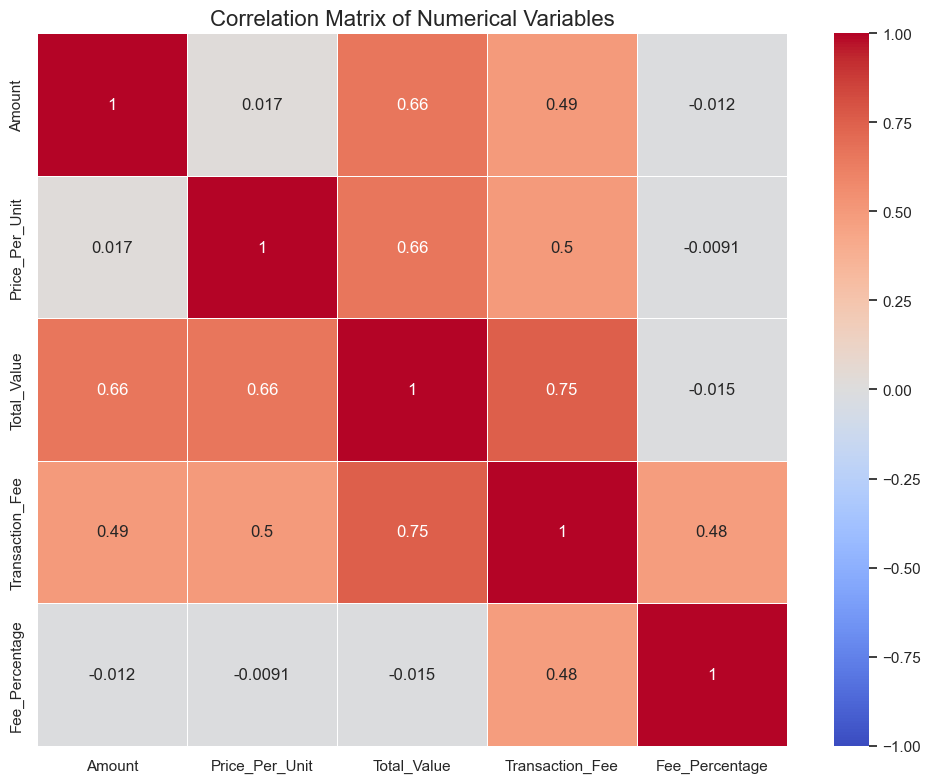

In [50]:
# correlation
numerical_cols = ['Amount', 'Price_Per_Unit', 'Total_Value', 'Transaction_Fee', 'Fee_Percentage']
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

Failed Transaction Distribution:
Transaction Type: {'Stake': np.float64(21.5), 'Transfer': np.float64(20.4), 'Buy': np.float64(20.1), 'Sell': np.float64(19.1), 'Withdraw': np.float64(18.8)}
Platform: {'KuCoin': np.float64(15.3), 'Coinbase': np.float64(15.0), 'Kraken': np.float64(14.6), 'Huobi': np.float64(14.5), 'FTX': np.float64(13.8), 'Binance': np.float64(13.5), 'OKX': np.float64(13.3)}
Wallet Type: {'Hot Wallet': np.float64(20.5), 'Exchange Wallet': np.float64(20.5), 'Trezor': np.float64(19.9), 'Ledger': np.float64(19.7), 'Cold Wallet': np.float64(19.4)}
Comparison of Failed vs Overall Transaction Distribution:
Percentage Point Difference in Failed Transactions:
Transaction Type: {'Buy': np.float64(0.1), 'Sell': np.float64(-1.2), 'Stake': np.float64(1.0), 'Transfer': np.float64(0.7), 'Withdraw': np.float64(-0.5)}
Platform: {'Binance': np.float64(-0.5), 'Coinbase': np.float64(-0.1), 'FTX': np.float64(-0.2), 'Huobi': np.float64(0.3), 'Kraken': np.float64(0.4), 'KuCoin': np.float64(0.

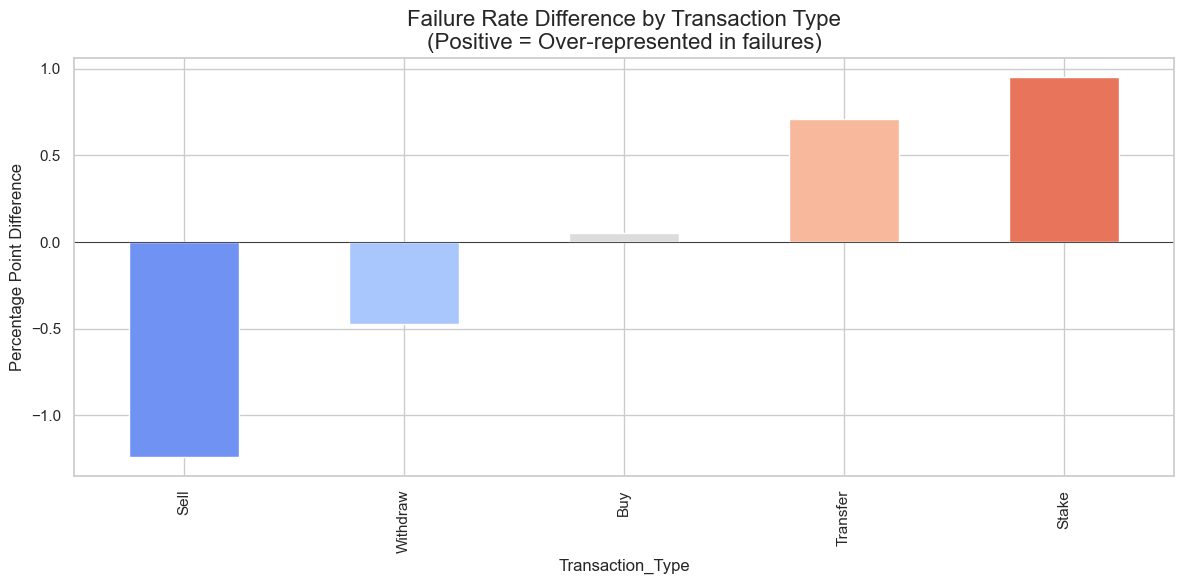

In [51]:
# Analyze failed transactions
failed_df = df[df['Status'] == 'Failed']
failed_by_type = failed_df['Transaction_Type'].value_counts(normalize=True) * 100
failed_by_platform = failed_df['Platform'].value_counts(normalize=True) * 100
failed_by_wallet = failed_df['Wallet_Type'].value_counts(normalize=True) * 100

print("Failed Transaction Distribution:")
print(f"Transaction Type: {dict(failed_by_type.round(1))}")
print(f"Platform: {dict(failed_by_platform.round(1))}")
print(f"Wallet Type: {dict(failed_by_wallet.round(1))}")

print("Comparison of Failed vs Overall Transaction Distribution:")
type_diff = failed_by_type - (df['Transaction_Type'].value_counts(normalize=True) * 100)
platform_diff = failed_by_platform - (df['Platform'].value_counts(normalize=True) * 100)
wallet_diff = failed_by_wallet - (df['Wallet_Type'].value_counts(normalize=True) * 100)

print("Percentage Point Difference in Failed Transactions:")
print(f"Transaction Type: {dict(type_diff.round(1))}")
print(f"Platform: {dict(platform_diff.round(1))}")
print(f"Wallet Type: {dict(wallet_diff.round(1))}")

plt.figure(figsize=(12, 6))
type_diff.sort_values().plot(kind='bar', color=sns.color_palette('coolwarm', len(type_diff)))
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Failure Rate Difference by Transaction Type\n(Positive = Over-represented in failures)', fontsize=16)
plt.ylabel('Percentage Point Difference')
plt.tight_layout()
plt.show()

KPI Calculations

Key Performance Indicators (KPIs):
Total Transaction Volume: $15,066,581,178.84
Total Transaction Count: 10,000
Total Transaction Fees: $375,550,808.50
Overall Success Rate: 33.22%
Average Transaction Value: $1,506,658.12
Average Transaction Fee: $37,555.08
Average Fee Percentage: 2.49%
Platform-Specific KPIs:
Best Performing Platform: Coinbase (Success Rate: 36.30%)
Most Cost-Effective Platform: Binance (Fee Percentage: 2.45%)

Cryptocurrency-Specific KPIs:
Most Popular Cryptocurrency: Polkadot (1077 transactions)
Highest Volume Cryptocurrency: Polkadot ($1,648,498,379.71)

Transaction Type KPIs:
Most Successful Transaction Type: Withdraw (Success Rate: 34.11%)
Highest Value Transaction Type: Buy (Avg. Value: $1,545,108.43)


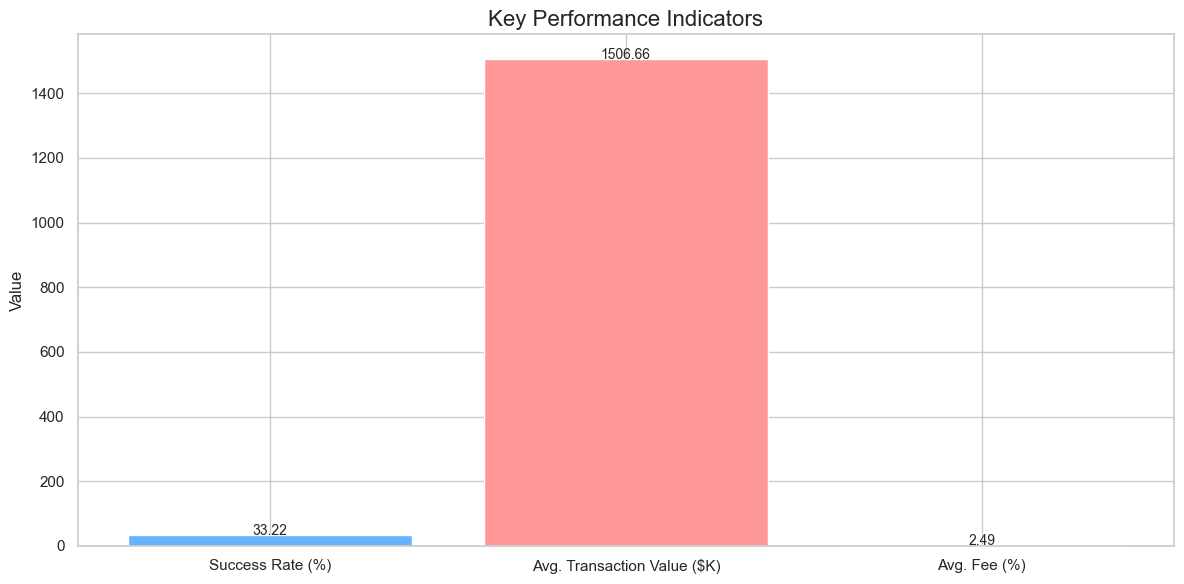

In [53]:
total_transaction_volume = df['Total_Value'].sum()
total_transaction_count = len(df)
total_fees = df['Transaction_Fee'].sum()
success_rate = len(df[df['Status'] == 'Completed']) / total_transaction_count * 100
avg_transaction_value = df['Total_Value'].mean()
avg_fee = df['Transaction_Fee'].mean()
avg_fee_percentage = (total_fees / total_transaction_volume) * 100

print("Key Performance Indicators (KPIs):")
print(f"Total Transaction Volume: ${total_transaction_volume:,.2f}")
print(f"Total Transaction Count: {total_transaction_count:,}")
print(f"Total Transaction Fees: ${total_fees:,.2f}")
print(f"Overall Success Rate: {success_rate:.2f}%")
print(f"Average Transaction Value: ${avg_transaction_value:,.2f}")
print(f"Average Transaction Fee: ${avg_fee:,.2f}")
print(f"Average Fee Percentage: {avg_fee_percentage:.2f}%")

best_platform = platform_success_rate.idxmax()
best_platform_rate = platform_success_rate.max()
most_cost_effective = platform_fee_pct.idxmin()
lowest_fee_ratio = platform_fee_pct.min()

print("Platform-Specific KPIs:")
print(f"Best Performing Platform: {best_platform} (Success Rate: {best_platform_rate:.2f}%)")
print(f"Most Cost-Effective Platform: {most_cost_effective} (Fee Percentage: {lowest_fee_ratio:.2f}%)")

most_popular_crypto = crypto_counts.idxmax()
most_popular_count = crypto_counts.max()
highest_volume_crypto = crypto_volume.idxmax()
highest_volume = crypto_volume.max()

print("\nCryptocurrency-Specific KPIs:")
print(f"Most Popular Cryptocurrency: {most_popular_crypto} ({most_popular_count} transactions)")
print(f"Highest Volume Cryptocurrency: {highest_volume_crypto} (${highest_volume:,.2f})")

most_successful_type = type_success_rate.idxmax()
highest_value_type = type_avg_value.idxmax()

print("\nTransaction Type KPIs:")
print(f"Most Successful Transaction Type: {most_successful_type} (Success Rate: {type_success_rate.max():.2f}%)")
print(f"Highest Value Transaction Type: {highest_value_type} (Avg. Value: ${type_avg_value.max():,.2f})")

# Create KPI visualization
kpi_data = {
    'KPI': ['Success Rate (%)', 'Avg. Transaction Value ($K)', 'Avg. Fee (%)'],
    'Value': [success_rate, avg_transaction_value/1000, avg_fee_percentage]
}

plt.figure(figsize=(12, 6))
bars = plt.bar(kpi_data['KPI'], kpi_data['Value'], color=['#66b3ff', '#ff9999', '#99ff99'])
plt.title('Key Performance Indicators', fontsize=16)
plt.ylabel('Value')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f"{height:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Summary

### Cryptocurrency Trends
1. Top Used Assets: BTC, ETH, BNB, and XRP dominate transaction counts.

2. Asset Volume: Bitcoin has the highest total transaction value, indicating it may be used for large-volume trades.

### Platform Usage
1. High-Volume Platforms: Binance, Coinbase, and Kraken are the most commonly used platforms.

2. Low-Traffic Platforms: Platforms like Kucoin and OKX have fewer transactions.

### Transaction Types
1. Most Common: "Buy" and "Sell" transactions account for the majority.

2. Others: “Transfer” transactions are fewer in number but sometimes have large total values.

### Wallet Types
1. Cold Wallets dominate (~40–50%), followed by Trezor and Ledger.

2. Suggests user preference for secure, offline storage.

### Transaction Fees
1. Average Fee: Moderate and fairly consistent across platforms and assets.

2. Outliers: A few transactions with high fees; likely due to high volume or asset type.

### Status Distribution
1. Success Rate: >95% of transactions are “Completed.”

2. Failures: A small number of “Failed” and “Pending” transactions exist, worth monitoring.

### Monthly Trends
1. Peak Months: High activity in certain months (e.g., April, August), possibly tied to market rallies or platform promotions.

2. Lull Periods: Some months show lower engagement, especially post-summer.


## Summary & Recommendations

1. Focus on Power Users of Top Assets
Observation: BTC, ETH, and BNB dominate both in volume and total transaction value.
Action: Build advanced features and incentives (like staking, swaps, price alerts) for these top assets. Segment power users by behavior (e.g., volume traded, wallet type) for loyalty perks or targeted outreach.

2. Improve Transfer UX and Gas Management
Observation: Transfers are fewer in number but often have high value or unusual fee spikes.
Action: Optimize UX around gas estimation and confirmation times.
Introduce educational prompts or preset fee tiers to avoid failed/pending transactions.

3. Expand Support and Visibility for Hardware Wallets
Observation: Cold wallets (like Trezor, Ledger) are a growing preference among users.
Action: Deepen Trust Wallet’s compatibility and UX with these devices.
Promote secure storage benefits within the app for new users transitioning from hot wallets.

4. Address Failed Transactions with Better Feedback Loops
Observation: A notable percentage of transactions fail.
Action: Create actionable, real-time in-app notifications that help users fix errors. Analyze failure reasons by network or transaction type for proactive support.